In [80]:
# Parameters
param1=1

In [81]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim_hyper import Config, run_sim
from utils import cosine_similarity, get_r_2, vector_angle
from tqdm import tqdm
from tqdm import tqdm
from utils import alignment_score
import matplotlib as mpl
from functools import reduce



In [82]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [101]:
C = Config()

C.G = 0.8
C.sig_h_2 = 1e-5
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.0001
C.corridor_dim = 2
C.L=10
C.print_progress = True
C.length_corridors = [10]*1
# C.input_size = 100
C.max_move = 4
C.hidden_size = 250 # sum(C.length_corridors)+2*C.max_move+1 + 10
C.num_epochs *= 1
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.bias = False
C.egocentric_movement = True
C.lambda_reg = 0
# C.whiten_data = True
# C.fixed_output = False
# C.split_actions = False
# C.allow_backwards = True

# C.min_move = 2
# C.one_hot_actions = True
# C.one_hot_inputs = False

In [102]:


X, y, corridor, loc_X, loc_y, action_taken, hidden_states, loss_l, accuracy_l, outputs, hidden_l, final_weights, initial_weights = run_sim(C)

print(calc_h_var(C.G, X.shape[1], C.hidden_size, C.L, X.var().cpu().numpy()))
print(f'Number of data points: {X.shape[0]} --- Shape of X,y: {X.shape}, {y.shape}')
print(f'Loss: {loss_l[-1]}, Accuracy: {accuracy_l[-1]}')
hidden = hidden_states[-1].detach().cpu().numpy()
X_dist = torch.cdist(X, X).cpu().numpy()
y_dist = torch.cdist(y, y).cpu().numpy()
hidden_dist = torch.cdist(hidden_states[-1].detach(), hidden_states[-1].detach()).cpu().numpy()
stay_inds = np.where(action_taken == 0)[0]
loc_y_corridor = loc_y + (corridor * max(loc_y + 1))
n_corridors = len(C.length_corridors)

X_np = X.cpu().numpy()  # Convert to numpy array if X is a torch tensor
y_np = y.cpu().numpy()  # Convert to numpy array if y is a torch tensor
h_np = hidden  # Convert to numpy array if hidden is a torch tensor

Changed G to 0.7505869269371033 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.0582366485323291e-05


100%|██████████| 10000/10000 [37:40<00:00,  4.42it/s]


tensor(1.0000e-05)
Number of data points: 7001 --- Shape of X,y: torch.Size([7001, 1036]), torch.Size([7001, 1023])
Loss: 0.04260372370481491, Accuracy: 0.9844307899475098


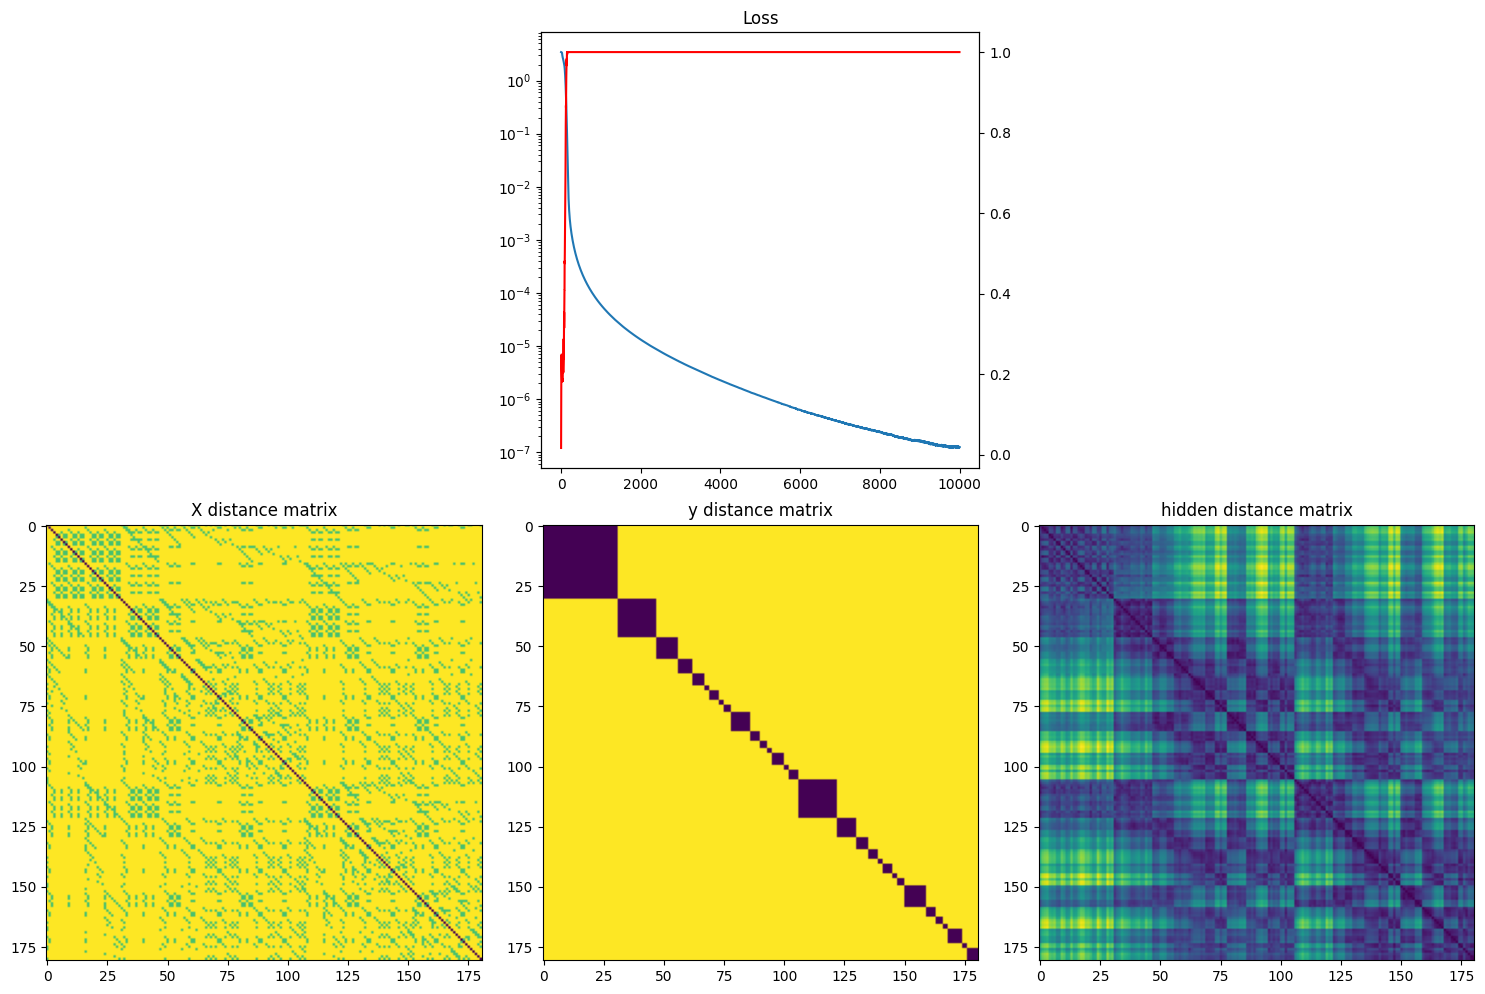

In [85]:
indices = np.lexsort((loc_y, corridor))
# indices = indices[action_taken[indices]==0]
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0,0].set_axis_off(); axs[0,2].set_axis_off()
axs[0,1].plot(loss_l)
axs[0,1].set_yscale('log')
axs[0,1].twinx().plot(accuracy_l, 'r')
axs[0,1].set_title("Loss")
for var, var_name, ax in zip([X_dist, y_dist, hidden_dist], ['X', 'y', 'hidden'], axs[1]):
    ax.imshow(var[indices][:, indices], cmap='viridis')
    ax.set_title(f'{var_name} distance matrix')
    ax.grid(False)
plt.tight_layout()
plt.show()

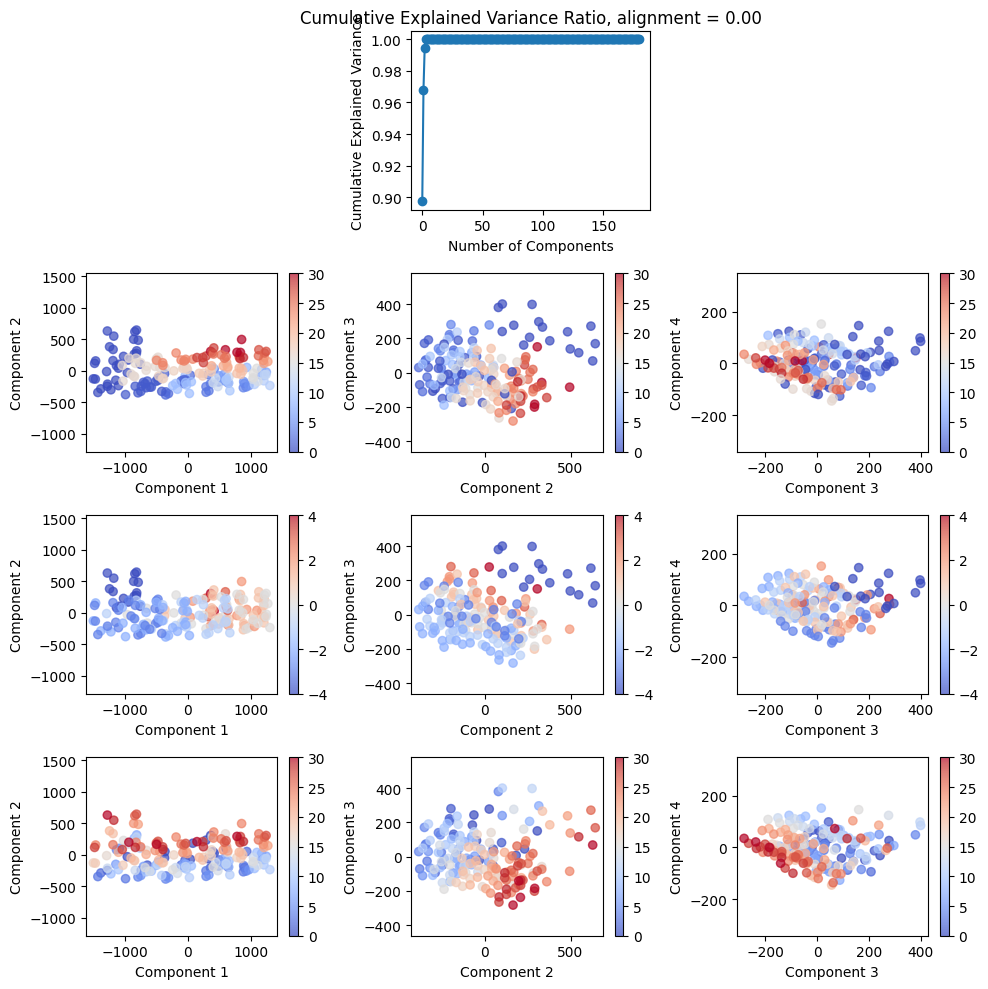

In [86]:
pca = PCA().fit(h_np)
# pca_corridors = [PCA() for i in range(n_corridors)]
# [p.fit(hidden[corridor==i]) for i, p in enumerate(pca_corridors)]
# alignment = np.mean([[cosine_similarity(pca_corridors[i].components_[0], pca_corridors[j].components_[0]) for j in
#                       range(n_corridors) if j!=i] for i in range(n_corridors)])
alignment = alignment_score(hidden[corridor==0], hidden[corridor==1]) if n_corridors > 1 else 0
X_reduced = pca.transform(h_np)
fig = plt.figure(figsize=(10, 10))

markers = list(mpl.markers.MarkerStyle.markers.keys())[2:]
# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(4, 3, 2)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title(f'Cumulative Explained Variance Ratio, alignment = {alignment:.2f}')

# Add scatter plots in the second row
for i in range(3):
    for j, c in enumerate([loc_y, action_taken, loc_X]):
        ax = fig.add_subplot(4, 3, i + 4 + j*3)
        # c = loc_y
        # c = action_taken[inds]
        for n in range(n_corridors):
            s = ax.scatter(X_reduced[corridor==n, i], X_reduced[corridor==n, i+1], c=c[corridor==n], cmap='coolwarm', alpha=0.7, marker=markers[n])
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}'),
        ax.axis('equal')
        fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()

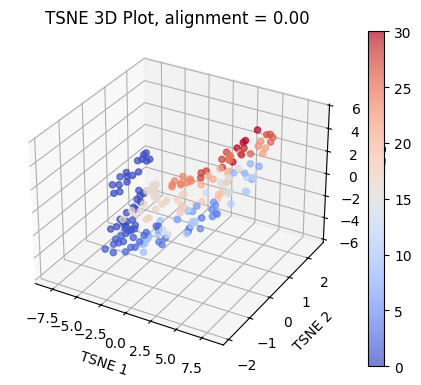

In [98]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, random_state=0)
alignment = alignment_score(hidden[corridor==0], hidden[corridor==1]) if n_corridors > 1 else 0
X_reduced = tsne.fit_transform(h_np)

fig = plt.figure(figsize=(20, 20))
markers = list(mpl.markers.MarkerStyle.markers.keys())[2:]

# Add title in first row
# Add 3D scatter plot
ax = fig.add_subplot(4, 3, 2, projection='3d')
for n in range(n_corridors):
    scatter = ax.scatter(X_reduced[corridor==n, 0], 
                        X_reduced[corridor==n, 1],
                        X_reduced[corridor==n, 2],
                        c=loc_y[corridor==n],
                        cmap='coolwarm',
                        alpha=0.7,
                        marker=markers[n])
ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2') 
ax.set_zlabel('TSNE 3')
ax.set_title(f'TSNE 3D Plot, alignment = {alignment:.2f}')
fig.colorbar(scatter, ax=ax)


In [87]:

output_weights = final_weights['output_layer.weight'].cpu().detach().numpy()
n_corridors = len(C.length_corridors)
pca = PCA(); pca_corridors = [PCA() for _ in range(n_corridors)];
[p.fit(hidden[corridor == i]) for i, p in enumerate(pca_corridors)]
pca.fit(hidden)
h_transformed = pca.transform(h_np)
h_transformed_l = [p.transform(h_np[corridor == i]) for i, p in enumerate(pca_corridors)]
pca_accuracy_l = []
pca_explained_var_l = []
pca_loss_l = []
order_l = []
n_pcs = np.arange(1, min(min([min(h_transformed_l[i].shape) for i in range(n_corridors)]), 100))
for n in n_pcs:
    # h_reconstructed = pca.inverse_transform(h_transformed)
    h_reconstructed = h_transformed[:,:n] @ pca.components_[:n] + pca.mean_
    y_hat_pca = (h_reconstructed @ output_weights.T)
    # print(f'accuracy of first {n} PCs: {(y_hat_first_pc == y.argmax(1).cpu().detach().numpy()).mean()}')
    pca_accuracy_l.append((y_hat_pca.argmax(1) == y_np.argmax(1)).mean())
    pca_explained_var_l.append(pca.explained_variance_ratio_[:n].sum())
    pca_loss_l.append(nn.CrossEntropyLoss()(torch.tensor(y_hat_pca), y.cpu()).item())
    order = [get_r_2(h[:, [n-1]], loc_y[corridor == i]) for i, h in enumerate(h_transformed_l)]
    order_l.append(np.mean(order))

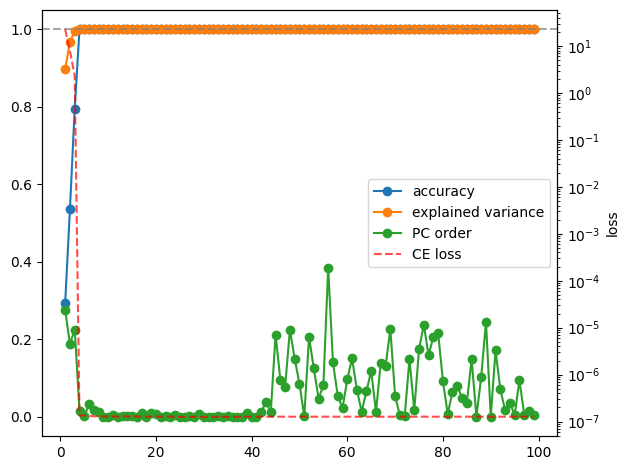

In [88]:
fig, ax1 = plt.subplots()
plt.plot(n_pcs, pca_accuracy_l, label='accuracy', marker='o')
plt.plot(n_pcs, pca_explained_var_l, label='explained variance', marker='o')
plt.plot(n_pcs, order_l, label='PC order', marker='o')
plt.axhline(1, color='gray', ls='--', alpha=0.7)
ax2 = ax1.twinx()
ax2.set_ylabel('loss')
ax2.plot(n_pcs, pca_loss_l, 'r', label='CE loss', ls='--', alpha=0.7)
ax2.set_yscale('log')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')
plt.xlabel('number of PCs')
# plt.xscale('log')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '$V_{11}$')

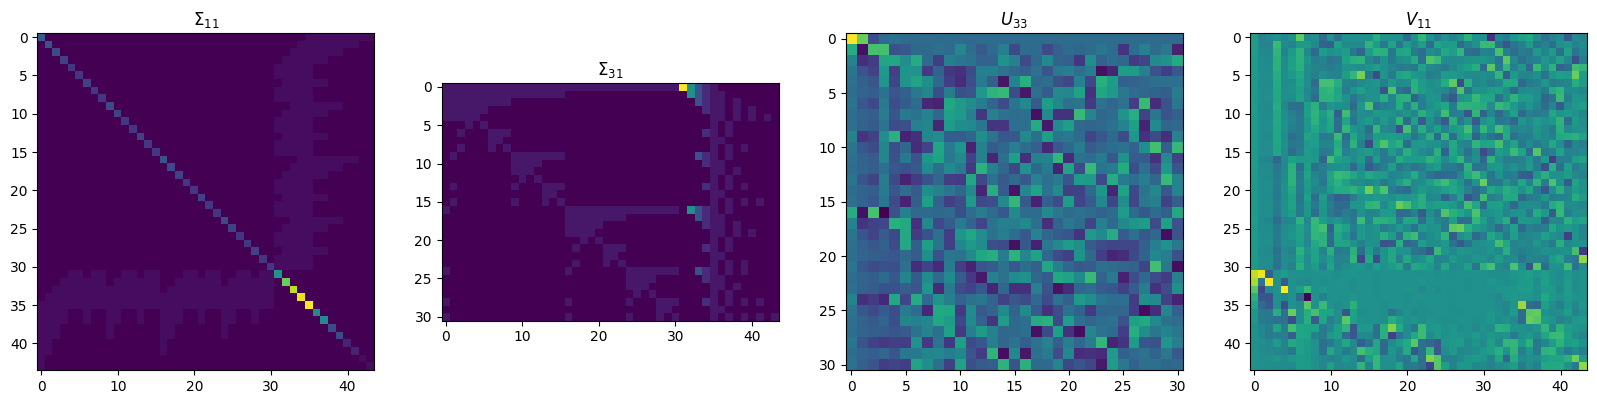

In [89]:

sigma11 = np.sum([xi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
U33,S, V11 = np.linalg.svd(sigma31)
V11 = V11.T

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
axs[0].imshow(sigma11); axs[0].set_title('$\Sigma_{11}$')
axs[1].imshow(sigma31); axs[1].set_title('$\Sigma_{31}$')
axs[2].imshow(U33); axs[2].set_title('$U_{33}$')
axs[3].imshow(V11); axs[3].set_title('$V_{11}$')

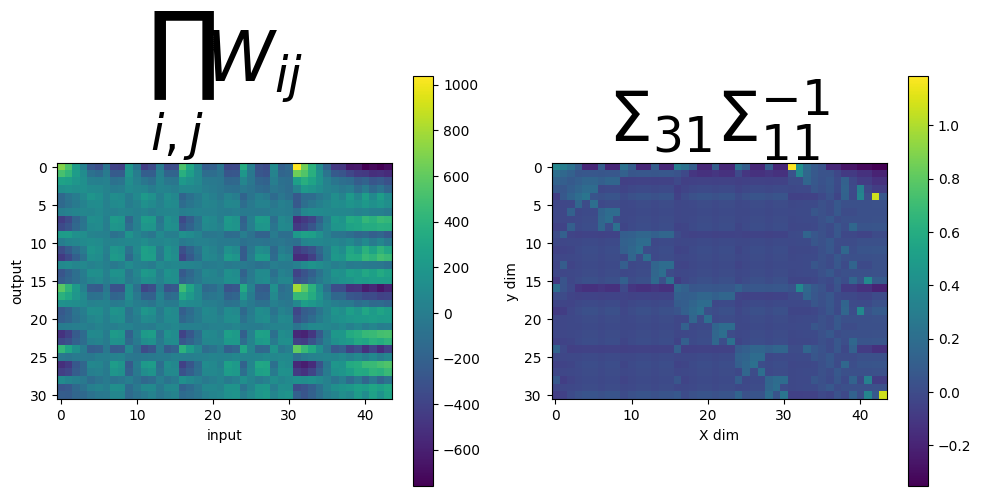

In [90]:
W_l = [W.cpu().numpy() for W in final_weights.values()]
result = W_l[0].T
for W in W_l[1:]:
    result = np.matmul(result, W.T)

# Sigma = np.corrcoef(X_np.T, y_np.T)
# Sigma31 = Sigma[X_np.shape[1]:, :X_np.shape[1]]
# Sigma11 = Sigma[:X_np.shape[1], :X_np.shape[1]]
Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X_np], 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
# ax1.imshow(W32@W21)
im = ax1.imshow(result.T, cmap='viridis')
plt.colorbar(im, ax=ax1)
ax1.set_ylabel('output')
ax1.set_xlabel('input')
ax1.set_title(r'$\prod_{i,j} W_{ij}$', fontsize=50)
im = ax2.imshow(Sigma31@np.linalg.pinv(Sigma11), cmap='viridis')
plt.colorbar(im, ax=ax2)
ax2.set_title('$\Sigma_{31}\Sigma_{11}^{-1}$', fontsize=50)
ax2.set_xlabel('X dim')
ax2.set_ylabel('y dim')
plt.tight_layout()
plt.show()

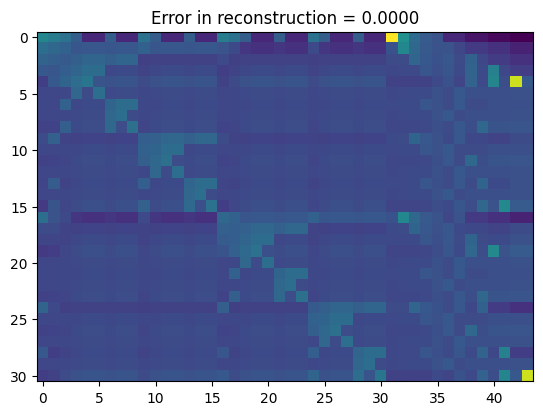

In [91]:
import numpy as np

def factorize_matrix(M, N=None):
    D1, D2 = M.shape
    # Compute full SVD
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    rank = np.sum(S > 1e-10)  # numerical rank

    if N is None:
        N = min(D1,D2)  # default N to rank(M)
    
    # Take the first N singular values
    U_N = U[:, :N] 
    S_N = np.diag(S[:N])
    Vt_N = Vt[:N, :]

    # Generate random orthogonal matrix
    Q = np.random.randn(N, N)
    Q, _ = np.linalg.qr(Q)
    
    # Create random factorization that still reconstructs M
    A = U_N @ np.sqrt(S_N) @ Q
    B = Q.T @ np.sqrt(S_N) @ Vt_N
    return A, B

# Example:
M = Sigma31@np.linalg.pinv(Sigma11)
A, B = factorize_matrix(M, N=None)
M_reconstructed = A @ B
plt.imshow(M_reconstructed)
plt.title(f'Error in reconstruction = {np.linalg.norm(M_reconstructed-M):.4f}')
plt.show()

In [92]:
h_syntetic = X_np @ B.T
pca = PCA().fit(h_syntetic)
X_reduced = pca.transform(h_syntetic)

lamb_h = PCA().fit(hidden).explained_variance_
lamb_h_syn = PCA().fit(h_syntetic).explained_variance_
lamb_out = PCA().fit(outputs).explained_variance_
lamb_tag = PCA().fit(X_np @ sigma31.T).explained_variance_
lamb_X = PCA().fit(X_np).explained_variance_
lamb_y = PCA().fit(y_np).explained_variance_
print(f'PR model hidden = {lamb_h.sum() ** 2 / (lamb_h ** 2).sum()}')
print(f'PR synthetic hidden = {lamb_h_syn.sum() ** 2 / (lamb_h_syn ** 2).sum()}')
print(f'PR model output = {lamb_out.sum() ** 2 / (lamb_out ** 2).sum()}')
print(f'PR sigma31 output = {lamb_tag.sum() ** 2 / (lamb_tag ** 2).sum()}')
print(f'PR X = {lamb_X.sum() ** 2 / (lamb_X ** 2).sum()}')
print(f'PR y = {lamb_y.sum() ** 2 / (lamb_y ** 2).sum()}')


PR model hidden = 1.2334944185218477
PR synthetic hidden = 14.772288417701349
PR model output = 1.2060601673976057
PR sigma31 output = 3.331995747820707
PR X = 24.399981608330144
PR y = 16.214055638433646


In [93]:
from sklearn.svm import LinearSVC
# Train hard-margin SVM (C is large => hard margin)
clf = LinearSVC(fit_intercept=True, C=1e-9)
clf.fit(X_np, y_np.argmax(1))
w_SVM = clf.coef_
print(clf.score(X_np, y_np.argmax(1)))
print(((X_np@w_SVM.T + clf.intercept_[None,:]).argmax(1)==y_np.argmax(1)).mean())

0.1712707182320442
0.1712707182320442


In [94]:
from functools import reduce
W_effective = reduce(np.matmul, [W.cpu().numpy().T for W in final_weights.values()])
Corr_matrix = Sigma31@np.linalg.pinv(Sigma11)
clf = LogisticRegression(multi_class='multinomial', penalty=None)
clf.fit(X_np, y_np.argmax(1))
print(f'Model accuracy = {((X_np@W_effective).argmax(1)==y_np.argmax(1)).mean():.2f}')
print(f'Corr matrix accuracy = {((X_np@Corr_matrix.T).argmax(1)==y_np.argmax(1)).mean():.2f}')
print(f'Logistic regression accuracy = {accuracy_score(clf.predict(X_np), y_np.argmax(1)):.2f}')



Model accuracy = 1.00
Corr matrix accuracy = 0.77
Logistic regression accuracy = 1.00


c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [95]:
L = C.length_corridors[0]
L_start = -L/2; L_end = L/2
A = C.max_move
n_model = 1
Win = np.concatenate([np.linspace(L_start,L_end, L), np.linspace(-A,A, 2*A+1)])[:,None]
Wout = 1/n_model*np.linspace(L_start,L_end, L)[None,:]**n_model
b = -1/(n_model+1)*np.linspace(L_start,L_end, L)[None, :]**(n_model+1)

print('Accuracy of tailored solution: ', ((X_np@Win@Wout+b).argmax(1)==(y_np.argmax(1))).mean())

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 14 is different from 44)

In [ ]:
A,B = get_AB(X_np, Win, Wout, b, C.hidden_size)
W_synthetic = (A@B).T
print('Accuracy of tailored solution: ', ((X_np@A@B).argmax(1)==(y_np.argmax(1))).mean())

In [ ]:
W_dict = {
    'W_model':reduce(np.matmul, [W.cpu().numpy().T for W in final_weights.values()]).T,
    'W_synthetic':W_synthetic,
    'W_logistic':LogisticRegression(multi_class='multinomial', fit_intercept=False, tol=1e-12).fit(X_np, y_np.argmax(1)).coef_,
    'W_logistic_noreg':LogisticRegression(multi_class='multinomial', penalty=None, fit_intercept=False, tol=1e-12).fit(X_np, y_np.argmax(1)).coef_,
    'W_correlation':Sigma31@np.linalg.pinv(Sigma11),
}
# for k,v in W_dict.items():
#     W_dict[k] = v/v.max()
fig, axs = plt.subplots(1, len(W_dict), figsize=(40,5))
for ax, (W_name, W) in zip(axs, W_dict.items()):
    # if W_name == 'W_loremote
    #  = W
    ax.imshow(W, cmap='coolwarm')
    lamb = PCA().fit(X_np@W.T).explained_variance_
    PRWX = lamb.sum() ** 2 / (lamb ** 2).sum()
    lamb = PCA().fit(W).explained_variance_
    PR = lamb.sum() ** 2 / (lamb ** 2).sum()
    ax.set_title(f'{W_name} --- acc={accuracy_score((X_np@W.T).argmax(1), y_np.argmax(1)):.2f} --- PR W={PR:.2f} --- PR WX={PRWX:.2f} --- W rank: {np.linalg.matrix_rank(W, tol=np.sqrt(lamb[0])*(1/W.shape[0]))}')
    ax.set_xticks(np.arange(X_np.shape[1]), [f's = {i}' for i in range(loc_y.max()+1)]+[f'a = {i}' for i in range(-C.max_move, C.max_move+1)], rotation=45)
    ax.grid(False)

In [ ]:
import torch
import torch.nn.functional as F

def compute_hessian(x, W_l, target):
    """
    Compute the Hessian of MSE loss w.r.t. the flattened parameters.

    Args:
        W_l (list of torch.Tensor): List of weight matrices (no bias).
        x (torch.Tensor): Input tensor of shape (batch_size, in_features).
        target (torch.Tensor): Target tensor of shape (batch_size, out_features).

    Returns:
        torch.Tensor: 2D Hessian matrix of shape (num_params, num_params).
    """
    # Make sure weights require gradients
    W_l = [torch.tensor(w).float().requires_grad_(True) for w in W_l]

    # Forward pass through layers
    out = x
    for W in W_l:
        out = out @ W.T  # Linear layer without bias

    # Loss (mean squared error)
    loss = F.cross_entropy(F.softmax(out, dim=1), target)

    # Flatten parameters
    params_vector = torch.cat([w.reshape(-1) for w in W_l])

    # Compute gradients (first-order)
    grads = torch.autograd.grad(loss, W_l, create_graph=True)
    grads_vector = torch.cat([g.reshape(-1) for g in grads])

    num_params = params_vector.numel()
    hessian = torch.zeros(num_params, num_params)

    for i in range(num_params):
        grad2rd = torch.autograd.grad(grads_vector[i], W_l, retain_graph=True)
        grad2rd_vector = torch.cat([g.contiguous().reshape(-1) for g in grad2rd])
        hessian[i] = grad2rd_vector

    return hessian


hessians = {}
plt.figure(figsize=(20,8))
ax = plt.gca()
for i, (W_name, W) in enumerate(W_dict.items()):
    print(f"Computing Hessian for {W_name}...")
    H = compute_hessian(torch.tensor(X_np), [100*W/np.linalg.norm(W)], y)
    hessians[W_name] = H
    
    # Print some properties of the Hessian
    eigvals = np.linalg.eigvals(H)
    print(f"Hessian eigenvalues - min: {np.min(np.real(eigvals)):.2e}, max: {np.max(np.real(eigvals)):.2e}")
    
    # Plot eigenvalues
    plt.subplot(1, len(W_dict), i+1, sharey=ax)
    eigvals = np.sort(np.real(eigvals))[::-1]
    plt.plot(eigvals, 'o-')
    plt.yscale('log')
    plt.title(f'{W_name} H eigs, sum={abs(np.real(eigvals)).sum():.4f}')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Plot eigenvalues for each W matrix
plt.figure(figsize=(20,8))
ax  = plt.gca()
for i, (W_name, W) in enumerate(W_dict.items()):
    # Calculate eigenvalues 
    W_norm = W/np.linalg.norm(W)
    eigenvals = np.linalg.eigvals(W_norm @ W_norm.T)
    eigenvals = np.sort(np.abs(eigenvals))[::-1]
    
    plt.subplot(1, len(W_dict), i+1, sharey=ax)
    plt.plot(eigenvals, 'o-')
    plt.yscale('log')
    plt.title(f'{W_name} Eigenvalues')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Calculate cross-entropy loss for each W matrix
losses = {}
for W_name, W in W_dict.items():
    # Get predictions
    W_norm = W/np.linalg.norm(W)
    logits = X_np @ W_norm.T
    
    # Apply softmax
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    
    # Calculate cross entropy loss
    loss = -np.mean(np.sum(y_np * np.log(probs + 1e-10), axis=1))
    losses[W_name] = loss
    print(f'Cross entropy loss for {W_name}: {loss:.4f}, accuracy: {(logits.argmax(1)==y_np.argmax(1)).mean()}')
# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(losses.keys(), losses.values())
plt.xticks(rotation=45)
plt.ylabel('Cross Entropy Loss')
plt.title('Cross Entropy Loss by Weight Matrix Type')
plt.tight_layout()
plt.yscale('log')
plt.show()



In [ ]:
# Create figure with subplots for each W matrix
fig, axs = plt.subplots(2, len(W_dict), figsize=(4*len(W_dict), 8))
axs = axs.T
for i, (W_name, W) in enumerate(W_dict.items()):
    # Factorize matrix and get synthetic hidden states
    if W_name == 'W_model':
        U, S, V = np.linalg.svd(W)
        W = U[:,:2]@np.diag(S[:2])@V[:2,:]
    A, B = factorize_matrix(W, N=None)
    h_synthetic = X_np @ B.T
    
    # Fit PCA
    pca = PCA().fit(h_synthetic)
    X_reduced = pca.transform(h_synthetic)
    
    # Plot explained variance ratio
    axs[i,0].plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    PR = pca.explained_variance_.sum()**2/(pca.explained_variance_**2).sum()
    axs[i,0].set_xlabel('Number of Components')
    axs[i,0].set_ylabel('Cumulative Explained Variance')
    axs[i,0].set_title(f'{W_name} - EV Ratio --- PR = {PR:.2f}')
    
    # Plot first two PCs colored by location
    s = axs[i,1].scatter(X_reduced[:, 0], X_reduced[:, 1], c=loc_y, 
                        cmap='coolwarm', alpha=0.7)
    axs[i,1].set_xlabel('PC1')
    axs[i,1].set_ylabel('PC2')
    axs[i,1].set_title(f'{W_name} - First 2 PCs')
    fig.colorbar(s, ax=axs[i,1])
    axs[i,1].axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_classification
    
# Train multiclass SVM using one-vs-rest strategy
clf = SVC(kernel='linear', C=1e-6, decision_function_shape='ovr')
clf.fit(X_np, y_np.argmax(1))
print(clf.score(X_np, y_np.argmax(1)))
# Number of classes
n_classes = len(np.unique(y_np.argmax(1)))

# Extract w_SVM and bias b for each class
w_SVM_all = clf.coef_  # shape (n_classes, n_features)
b_all = clf.intercept_  # shape (n_classes,)


In [ ]:
from tqdm import tqdm
lamb_h_l = []
for h in tqdm(hidden_l[::10]):
    lamb_h_l.append(PCA().fit(h[-1]).explained_variance_)

In [ ]:
plt.plot([lamb.sum()**2/(lamb**2).sum() for lamb in lamb_h_l])
plt.ylabel('PR of last hidden layer')
plt.xlabel('Epochs')
plt.ylim(0)

In [729]:
# # Compute participation ratio for a matrix
# def compute_participation_ratio(matrix):
#     eigenvalues = np.linalg.eigvalsh(matrix @ matrix.T)  # Compute eigenvalues of the covariance matrix
#     eigenvalues = eigenvalues[eigenvalues > 1e-10]  # Filter out near-zero eigenvalues for numerical stability
#     pr = (np.sum(eigenvalues) ** 2) / np.sum(eigenvalues ** 2)
#     return pr
#
# # Compute PR for each weight matrix in final_weights
# participation_ratios = {}
# for name, weight in final_weights.items():
#     weight_np = weight.cpu().detach().numpy()  # Convert to numpy
#     participation_ratios[' '.join(name.split('.')[:-1])] = compute_participation_ratio(weight_np)
#
# # Compute PR for each weight matrix in final_weights
# participation_ratios_h = {}
# for i, h in enumerate([X] + hidden_states + [y]):
#     hid_np = h.cpu().detach().numpy()  # Convert to numpy
#     participation_ratios_h[f'hidden_{i+1}'] = compute_participation_ratio(hid_np)
#
# # Plot the participation ratios
# fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 6))
# ax1.plot(participation_ratios.keys(), participation_ratios.values(), color='skyblue')
# ax1.set_ylim(0)
# ax1.set_xticklabels(participation_ratios.keys(), rotation=45, ha='right')
# ax2.plot(participation_ratios_h.keys(), participation_ratios_h.values(), color='orange')
# # ax2.set_xticks(rotation=45, ha='right')
# ax1.set_ylabel('Participation Ratio')
# ax2.set_ylim(0)
# fig.suptitle('Participation Ratio of Weight Matrices and hiddens')
# plt.tight_layout()
# plt.show()

In [ ]:
n_actions = X.shape[1] - sum(C.length_corridors)
a_in_hidden = np.concatenate([np.zeros([n_actions, y.shape[1]]), np.eye(n_actions)],1)
n_states = X.shape[1] - n_actions
s_in_hidden = np.concatenate([np.eye(n_states), np.zeros([n_states, n_actions])],1)
for W in W_l[:-1]:
    a_in_hidden = a_in_hidden @ W.T
    s_in_hidden = s_in_hidden @ W.T

colors = plt.cm.jet(np.linspace(0, 1, a_in_hidden.shape[1]))
for i, color in enumerate(colors):
    plt.plot(np.arange(n_actions), a_in_hidden[:, i], color=color)
plt.xlabel('action')
plt.ylabel('hidden state')
plt.title('Action representation in hidden state, each line is a neuron')
plt.show()


In [ ]:
from utils import get_upper_triangle

d_b = []
d_n = []
for h in tqdm(hidden_l[1::10]):
    h = torch.tensor(h[-1]).to('cuda:2' if torch.cuda.is_available() else 'cpu')
    hidden_centers = torch.stack([h[y[:,i]==1].mean(0) for i in range(y.shape[1])])
    hidden_between_cluster_dists = torch.diag(torch.cdist(hidden_centers, hidden_centers),1).mean().item()
    hidden_within_cluster_dists = torch.tensor([get_upper_triangle(torch.cdist(h[y[:,i]==1], h[y[:,i]==1])).mean() for i in range(y.shape[1])]).mean().item()
    hidden_mean_norm = torch.linalg.norm(h, dim=1).mean().item()
    d_n.append(hidden_within_cluster_dists / hidden_mean_norm)
    d_b.append(hidden_within_cluster_dists / hidden_between_cluster_dists)
print(f'Within cluster distance normalized by between cluster distances: {d_b[-1]:.2f}')
print(f'Within cluster distance normalized by mean hidden norm: {d_n[-1]:.2f}')

plt.plot(d_b, label='between cluster distances')
plt.plot(d_n, label='mean hidden norm')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Distance')
plt.show()

In [732]:
import torch
import torch.nn.functional as F

def compute_hessian(W_l, x, target):
    """
    Compute the Hessian of MSE loss w.r.t. the flattened parameters.

    Args:
        W_l (list of torch.Tensor): List of weight matrices (no bias).
        x (torch.Tensor): Input tensor of shape (batch_size, in_features).
        target (torch.Tensor): Target tensor of shape (batch_size, out_features).

    Returns:
        torch.Tensor: 2D Hessian matrix of shape (num_params, num_params).
    """
    # Make sure weights require gradients
    W_l = [w.clone().detach().requires_grad_(True) for w in W_l]

    # Forward pass through layers
    out = x
    for W in W_l:
        out = out @ W.T  # Linear layer without bias

    # Loss (mean squared error)
    loss = F.mse_loss(out, target)

    # Flatten parameters
    params_vector = torch.cat([w.view(-1) for w in W_l])

    # Compute gradients (first-order)
    grads = torch.autograd.grad(loss, W_l, create_graph=True)
    grads_vector = torch.cat([g.view(-1) for g in grads])

    num_params = params_vector.numel()
    hessian = torch.zeros(num_params, num_params)

    for i in range(num_params):
        grad2rd = torch.autograd.grad(grads_vector[i], W_l, retain_graph=True)
        grad2rd_vector = torch.cat([g.contiguous().view(-1) for g in grad2rd])
        hessian[i] = grad2rd_vector

    return hessian


In [ ]:
num_params = sum([len(W.flatten()) for W in W_l])**2
print(num_params)
if num_params < 1e7:
    weights_for_hess = [W for W in final_weights.values()]
    hessian = compute_hessian(weights_for_hess, X, y)
    L, V = torch.linalg.eig(hessian)
    plt.figure(figsize=(12, 6))
    plt.plot(np.abs(L.numpy()))
    plt.yscale('log')


In [ ]:
sing_vals = [np.linalg.svd(W_l[i])[1] for i in range(C.L)]
plt.figure(figsize=(12, 6))
h=[plt.plot(s) for s in sing_vals]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

matrix_l = [X_np] + [W.T for W in W_l] + [y_np.T]
matrix_names = ['X'] + [f'W_{i}' for i in range(len(W_l))] + ['y']
num_mats = len(matrix_l)
# Step 1: Compute SVDs
svd_results = []
for W in matrix_l:
    U, S, Vt = np.linalg.svd(W)
    svd_results.append({'U': U, 'S': S, 'V': Vt.T})  # Vt.T gives V

# Step 2: Compute correlations between V_l and U_{l+1}
correlations = []
for l in range(num_mats - 1):
    V_l = svd_results[l]['V']  # Output singular vectors of W_l
    U_next = svd_results[l + 1]['U']  # Input singular vectors of W_{l+1}
    S = [svd_results[l]['S'], svd_results[l+1]['S']]
    S = S[np.argmax([min(S[0].shape), min(S[1].shape)])]

    # Compute correlation matrix (dot product between vectors)
    corr_matrix = np.abs(V_l @ U_next)

    # Aggregate correlation (e.g., mean of diagonal as measure)
    corrs = (np.diag(corr_matrix) * S).sum() / S.sum()
    correlations.append(corrs)

# Step 3: Plot
plt.figure(figsize=(8, 5))
plt.plot(range(num_mats-1), correlations, marker='o')
plt.xlabel('Layer (l)')
plt.xticks(range(num_mats-1), [f'{matrix_names[i]} to {matrix_names[i + 1]}' for i in range(num_mats-1)], rotation=45)
plt.ylabel('Mean correlation between V_l and U_{l+1}')
plt.title('Correlation between adjacent layers\' singular vectors')
plt.grid(True)
plt.show()


In [ ]:
h = [plt.plot(svd['S'], label=name) for svd, name in zip(svd_results, matrix_names)]
plt.legend()

In [ ]:
W_l = [W.cpu().numpy() for W in final_weights.values()]
ratios = []
for W in W_l:
    spectral_norm = np.linalg.norm(W, ord=2)
    frobenius_norm = np.linalg.norm(W, ord='fro')
    ratio = spectral_norm / frobenius_norm if frobenius_norm != 0 else np.nan
    ratios.append(ratio)
plt.plot(ratios)

In [ ]:
from scipy.sparse.linalg import svds
from utils import calc_NC1
classes = np.unique(y_np.argmax(1))
NC1_l = []
for h in tqdm(hidden_l):
    NC1_l.append(calc_NC1(h[-1], y_np.argmax(1)))

plt.plot(NC1_l)
plt.title('NC1')
plt.xlabel('Epoch')
plt.yscale('log')

In [ ]:
NC1_l[-1]

In [ ]:
classes = np.unique(y_np.argmax(1))
y_i = y_np.argmax(1)
hidden_centers = [hidden[y_i==c].mean(0) for c in classes]
hidden_centers = np.stack([h/np.linalg.norm(h) for h in hidden_centers])
Wout = final_weights['output_layer.weight'].cpu().numpy()
Wout /= np.linalg.norm(Wout, axis=1)[:, None]

plt.imshow(Wout@hidden_centers.T)
plt.colorbar()
plt.show()
plt.plot(np.diagonal(Wout@hidden_centers.T))

In [741]:
import torch
import torch.nn.functional as F

def compute_nc_metrics(features, labels, classifier_weights=None, test_features=None):
    """
    Compute NC1–NC4 metrics for neural collapse.

    Arguments:
        features: (N, d) tensor of training features.
        labels: (N,) tensor of class labels in 0...C-1.
        classifier_weights: (C, d) tensor of final layer weights (optional, for NC3).
        test_features: (M, d) tensor of test features (optional, for NC4).

    Returns:
        dict of NC1–NC4 values.
    """
    device = features.device
    features = features.float()
    labels = labels.long()

    classes = torch.unique(labels)
    C = len(classes)
    d = features.shape[1]

    # Compute class means
    class_means = []
    for c in classes:
        class_features = features[labels == c]
        class_mean = class_features.mean(dim=0)
        class_means.append(class_mean)
    class_means = torch.stack(class_means)  # shape (C, d)

    # Compute global mean
    global_mean = features.mean(dim=0)

    # Compute within-class scatter matrix (Sw)
    Sw = 0
    for c in classes:
        class_features = features[labels == c]
        mean_c = class_means[c]
        centered = class_features - mean_c
        Sw += (centered.T @ centered)
    Sw /= features.shape[0]

    # Compute between-class scatter matrix (Sb)
    centered_means = class_means - global_mean
    Sb = centered_means.T @ centered_means / C

    # ---- NC1: Ratio of within-class variance to between-class variance ----
    nc1 = torch.trace(Sw) / torch.trace(Sb)

    # ---- NC2: Cosine similarity matrix of class means ----
    norm_means = F.normalize(class_means, dim=1)
    cosine_matrix = norm_means @ norm_means.T
    off_diag_mask = ~torch.eye(C, dtype=bool, device=device)
    nc2 = cosine_matrix[off_diag_mask].std()

    # ---- NC3: Cosine similarity between classifier weights and class means ----
    if classifier_weights is not None:
        classifier_weights = F.normalize(classifier_weights.float(), dim=1)
        norm_means = F.normalize(class_means, dim=1)
        cos_sim = (classifier_weights * norm_means).sum(dim=1)
        nc3 = 1 - cos_sim.mean()
    else:
        nc3 = None

    # ---- NC4: Compare train and test class mean structures ----
    if test_features is not None:
        test_class_means = []
        for c in classes:
            test_class_features = test_features[labels == c]
            mean = test_class_features.mean(dim=0)
            test_class_means.append(mean)
        test_class_means = torch.stack(test_class_means)
        test_class_means = F.normalize(test_class_means, dim=1)
        norm_means = F.normalize(class_means, dim=1)
        cos_sim = (test_class_means * norm_means).sum(dim=1)
        nc4 = 1 - cos_sim.mean()
    else:
        nc4 = None

    return {
        "NC1": nc1.item(),
        "NC2_std_cosine": nc2.item(),
        "NC3_1-mean_cos": nc3.item() if nc3 is not None else None,
        "NC4_1-mean_cos": nc4.item() if nc4 is not None else None,
    }


In [ ]:
compute_nc_metrics(hidden_states[-1], y.argmax(1), classifier_weights=final_weights['output_layer.weight'], test_features=None)